In [6]:
import ast

s = '''
match x:
    case Point(P(), "y"):
        pass

'''

print(ast.dump(ast.parse(s), indent=2))

Module(
  body=[
    Match(
      subject=Name(id='x', ctx=Load()),
      cases=[
        match_case(
          pattern=MatchClass(
            cls=Name(id='Point', ctx=Load()),
            patterns=[
              MatchClass(
                cls=Name(id='P', ctx=Load())),
              MatchValue(
                value=Constant(value='y'))]),
          body=[
            Pass()])])])


GlobalCall(def_id=DefId(id=236), args=[PlaceNode(place=Variable(name='b', ty=OpaqueType(args=[], defn=OpaqueTypeDef(id=DefId(id=4), name='bool', defined_at=None, description='type', params=[], never_copyable=False, never_droppable=False, to_hugr=<function <lambda> at 0x118a4f060>, bound=None)), defined_at=arg(arg='b', annotation=Name(id='bool', ctx=Load()), type_comment=None), flags=<InputFlags.NoFlags: 0>, is_func_input=True)), PlaceNode(place=Variable(name='c', ty=OpaqueType(args=[], defn=OpaqueTypeDef(id=DefId(id=4), name='bool', defined_at=None, description='type', params=[], never_copyable=False, never_droppable=False, to_hugr=<function <lambda> at 0x118a4f060>, bound=None)), defined_at=arg(arg='c', annotation=Name(id='bool', ctx=Load()), type_comment=None), flags=<InputFlags.NoFlags: 0>, is_func_input=True))], type_args=[])
def id:  DefId(id=236)
type args:  []
arg:  PlaceNode(place=Variable(name='b', ty=OpaqueType(args=[], defn=OpaqueTypeDef(id=DefId(id=4), name='bool', defined_

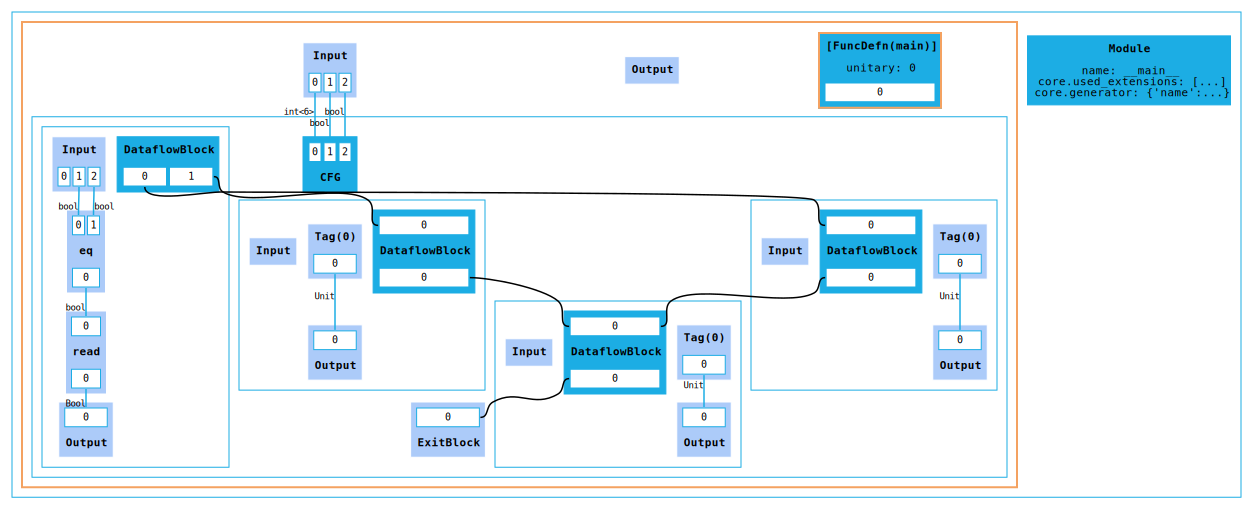

In [1]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy
def f(x: int) -> int:
    y = x + 1
    return y

@guppy
def main(a: int, b: bool, c : bool) -> None:
    if b == c:
        pass

main.compile_function().modules[0].render_dot()

In [1]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy
def f(x: int) -> int:
    y = x + 1
    return y

@guppy
def main(b: bool, m: int) -> None:
    l = True
    match l:
        case True:
            pass


main.compile_function().modules[0].render_dot()

Traceback (most recent call last):
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/.devenv/state/venv/lib/python3.14/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/sx/bbzfd6mn5txdvh5bghnjgp5m0000gp/T/ipykernel_15740/570937899.py", line 17, in <module>
    main.compile_function().modules[0].render_dot()
    ~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang/src/guppylang/defs.py", line 205, in compile_function
    return super().compile()
           ~~~~~~~~~~~~~~~^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang/src/guppylang/defs.py", line 77, in compile
    package: Package = ENGINE.compile(self.id).package
                       ~~~~~~~~~~~~~~^^^^^^^^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang-internals/src/guppylang_internals/error.py

In [ ]:
from guppylang import guppy

@guppy
def main() -> int:
    x = True
    return 3


main.compile_function().modules[0].render_dot()

In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned, h

@guppy.struct
class Point:
    y: int

@guppy
def fun() -> Point:
    return Point( 4)

@guppy
def main(p: Point) -> None:
    s = Point(0)
    if s == p:
        pass


main.compile_function()


GlobalCall(def_id=DefId(id=369), args=[PlaceNode(place=FieldAccess(parent=Variable(name='p', ty=StructType(args=[], defn=CheckedStructDef(id=DefId(id=365), name='Struct', defined_at=ClassDef(name='Struct', bases=[], keywords=[], body=[AnnAssign(target=Name(id='x', ctx=Store(...)), annotation=Name(id='int', ctx=Load(...)), value=None, simple=1)], decorator_list=[Attribute(value=Name(id='guppy', ctx=Load(...)), attr='struct', ctx=Load())], type_params=[]), description='type', params=[], fields=[CheckedField(name='x', ty=NumericType(kind=<Kind.Int: 2>))])), defined_at=arg(arg='p', annotation=Name(id='Struct', ctx=Load()), type_comment=None), flags=<InputFlags.NoFlags: 0>, is_func_input=True), field=CheckedField(name='x', ty=NumericType(kind=<Kind.Int: 2>)), exact_defined_at=None))], type_args=[])
def id:  DefId(id=369)
type args:  []
arg:  PlaceNode(place=FieldAccess(parent=Variable(name='p', ty=StructType(args=[], defn=CheckedStructDef(id=DefId(id=365), name='Struct', defined_at=ClassDef

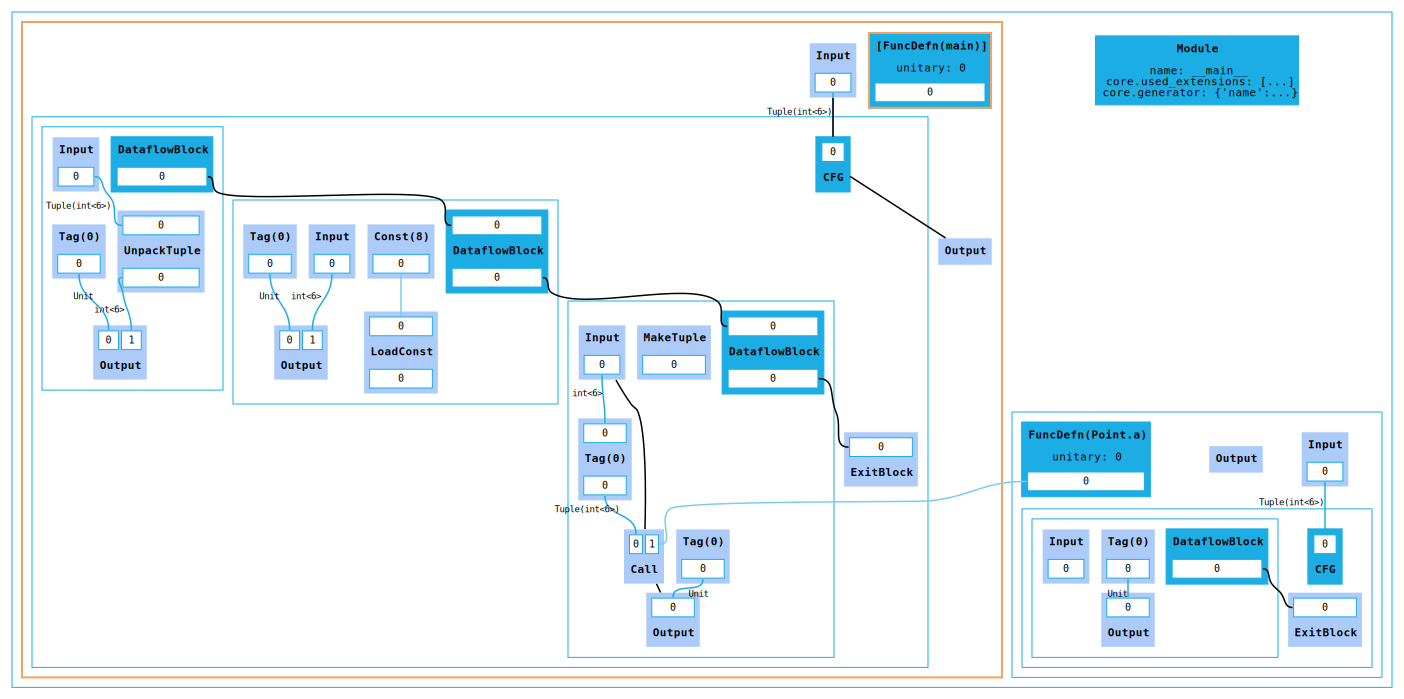

In [2]:


# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned, h

@guppy.enum
class Point:
    x = {"n": int}

    @guppy
    def a(self:Point) -> None:
        pass

@guppy.struct
class Struct:
    x: int

@guppy
def fun() -> Point:
    return Point.x(qubit())

@guppy
def main(p: Struct) -> None:
    match p:
        case _:
            x = 8
    
    s = Point.x(p.x)
    s.a()

main.compile_function().modules[0].render_dot()


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, h

@guppy.struct
class Point:
    x: qubit
    y: int

@guppy
def fun() -> Point:
    return Point(qubit(), 4)

@guppy
def describe_point(point: Point)-> None:
    pass

@guppy
def main(p: Point) -> None:

    describe_point(fun())

main.check()


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure

@guppy.enum
class Point:
    x = {"n": bool}
    y = {"n": int}

    @guppy
    def met(self: Point) -> int:
@guppy.enum
class Point:
    x = {"n": bool}
    y = {"n": int}

    @guppy
    def met(self: Point) -> int:
        match self:
            case Point.x(True):
                return 42
            case Point.y(val):
                return val
            case Point.y(_):
                return 2
            case Point.y(val):
                return val
            case Point.y(_):
                return 2


@guppy
def main(p: Point) -> None:
    e = Point.y(1)
    e.met()

    # describe_point(fun())

main.compile_function().modules[0].render_dot().view()


In [ ]:
from guppylang import guppy

@guppy.struct
class Point:
    x: int
    y: int

@guppy
def main(p: Point) -> None:
    match p:
        case Point(_, _):
            b = 1
    a = b

main.check()

In [ ]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy.enum
class Point:
    x = {"n": int}
    y = {"n": int}
    z = {"n": int}

    @guppy
    def enum(self: Point) -> None:
        pass

@guppy.struct
class Line:
    start: int
    end: int

    @guppy
    def struct(self: Line) -> None:
        pass

@guppy
def main() -> None:
    p = Point.x(1)
    p.enum()
    l = Line(2, 3)
    l.struct()

main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=100)).view()
    